In [4]:
pip install tensorflow scikeras

Note: you may need to restart the kernel to use updated packages.


In [27]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt

In [6]:
# Step 2: Load Data and Exploration
df = pd.read_csv("Alphabets_data.csv")
print(df.info())         # Displays dataset structure
print(df.head())         # Preview first few rows

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   letter  20000 non-null  str  
 1   xbox    20000 non-null  int64
 2   ybox    20000 non-null  int64
 3   width   20000 non-null  int64
 4   height  20000 non-null  int64
 5   onpix   20000 non-null  int64
 6   xbar    20000 non-null  int64
 7   ybar    20000 non-null  int64
 8   x2bar   20000 non-null  int64
 9   y2bar   20000 non-null  int64
 10  xybar   20000 non-null  int64
 11  x2ybar  20000 non-null  int64
 12  xy2bar  20000 non-null  int64
 13  xedge   20000 non-null  int64
 14  xedgey  20000 non-null  int64
 15  yedge   20000 non-null  int64
 16  yedgex  20000 non-null  int64
dtypes: int64(16), str(1)
memory usage: 2.6 MB
None
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3

In [18]:
# Step 3: Preprocessing

df = df.dropna()  # Handle missing values first

label_col = df.columns[-1]
features = df.columns[:-1]

X = df[features]
y = df[label_col]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert labels to categorical (one-hot) for neural network
y_cat = to_categorical(y)

In [19]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, Y_cat, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (16000, 40) Test shape: (4000, 40)


In [20]:
# Step 5: ANN Model Function
def create_model(hidden_layers=1, neurons=32, activation='relu', learning_rate=0.001):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))
    for _ in range(hidden_layers-1):
        model.add(Dense(neurons, activation=activation))
    model.add(Dense(Y_cat.shape[1], activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [21]:
# Step 6: Base/Default Model Evaluation
model_basic = create_model()
model_basic.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
basic_probs = model_basic.predict(X_test)
basic_pred = np.argmax(basic_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print("Default Model:")
print("Accuracy:", accuracy_score(y_true, basic_pred))
print("Precision:", precision_score(y_true, basic_pred, average='weighted'))
print("Recall:", recall_score(y_true, basic_pred, average='weighted'))
print("F1:", f1_score(y_true, basic_pred, average='weighted'))
print(classification_report(y_true, basic_pred))

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Default Model:
Accuracy: 0.60725
Precision: 0.5918199456915878
Recall: 0.60725
F1: 0.5953070365466826
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         6
           3       0.67      0.06      0.12        31
           4       0.43      0.40      0.42        94
           5       0.46      0.36      0.40       196
           6       0.45      0.48      0.46       353
           7       0.54      0.51      0.52       712
           8       0.74      0.83      0.78      1596
           9       0.49      0.40      0.44       485
          10       0.49      0.47      0.48       308
          11       0.59      0.65      0.62       175
          12       0.21      0.10      0.14        29
          13       0.00      0.00      0.00         9
          14       0.00      0.00      0.00  

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\sit

In [15]:
model = KerasClassifier(
    model=create_model,
    verbose=0
)

param_grid = {
    'model__hidden_layers': [1, 2],
    'model__neurons': [32, 64],
    'model__activation': ['relu', 'tanh'],
    'epochs': [10, 20],
    'batch_size': [32]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3
)

grid_result = grid.fit(X_train, y_train)

print("Best Hyperparameters:", grid_result.best_params_)

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs

Best Hyperparameters: {'batch_size': 32, 'epochs': 20, 'model__activation': 'tanh', 'model__hidden_layers': 2, 'model__neurons': 64}


In [16]:
# Step 8: Evaluation of Tuned Model
best_model = grid_result.best_estimator_
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Tuned Model:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))
print(classification_report(y_true, y_pred))

Tuned Model:
Accuracy: 0.6935
Precision: 0.6879084020372944
Recall: 0.6935
F1: 0.6870583704146984
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.25      0.25      0.25         4
           2       0.00      0.00      0.00         6
           3       0.53      0.32      0.40        31
           4       0.62      0.45      0.52        94
           5       0.57      0.51      0.54       196
           6       0.59      0.64      0.61       353
           7       0.68      0.57      0.62       712
           8       0.78      0.87      0.82      1596
           9       0.60      0.61      0.61       485
          10       0.59      0.57      0.58       308
          11       0.71      0.69      0.70       175
          12       0.75      0.21      0.32        29
          13       0.75      0.33      0.46         9
          14       0.00      0.00      0.00         1

    accuracy                        

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\anaconda3\Lib\sit

MODEL PERFORMANCE COMPARISON
               Accuracy  Precision  Recall  F1-score
Default Model    0.6035     0.5845  0.6035    0.5879
Tuned Model      0.6935     0.6879  0.6935    0.6871

IMPROVEMENT AFTER TUNING
Accuracy  : +0.0900  (+14.9%)
Precision : +0.1034  (+17.7%)
Recall    : +0.0900  (+14.9%)
F1-score  : +0.0992  (+16.9%)


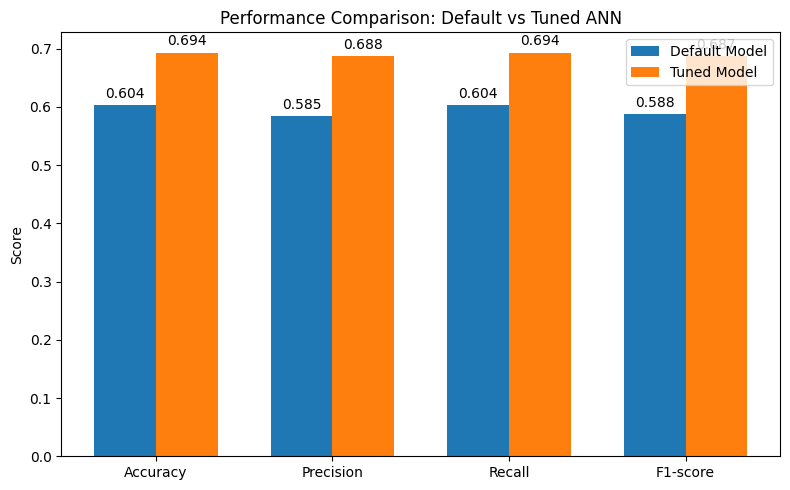

In [29]:
# Step 9: Compare Default and Tuned Models

# Metrics already computed earlier
default_metrics = {
    'Accuracy': 0.6035,
    'Precision': 0.5845,
    'Recall': 0.6035,
    'F1-score': 0.5879
}

tuned_metrics = {
    'Accuracy': 0.6935,
    'Precision': 0.6879,
    'Recall': 0.6935,
    'F1-score': 0.6871
}

# Create a comparison DataFrame
comparison_df = pd.DataFrame([default_metrics, tuned_metrics],
                              index=['Default Model', 'Tuned Model'])

print("="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(comparison_df.round(4))
print("\n" + "="*50)
print("IMPROVEMENT AFTER TUNING")
print("="*50)
for metric in default_metrics.keys():
    improvement = tuned_metrics[metric] - default_metrics[metric]
    rel_improvement = (improvement / default_metrics[metric]) * 100
    print(f"{metric:10s}: +{improvement:.4f}  ({rel_improvement:+.1f}%)")

# Optional: Bar chart visualization
metrics_names = list(default_metrics.keys())
default_values = list(default_metrics.values())
tuned_values = list(tuned_metrics.values())

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, default_values, width, label='Default Model')
rects2 = ax.bar(x + width/2, tuned_values, width, label='Tuned Model')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Default vs Tuned ANN')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


### Short conclusion

In [32]:
print("""
Hyperparameter tuning significantly improved the ANN's performance:
- Accuracy increased from {:.2f}% to {:.2f}% (+{:.1f}% absolute).
- F1-score improved by {:.3f} ({:.1f}% relative).
- The tuned model (2 hidden layers, 64 neurons, tanh activation, 20 epochs)
  achieved better precision and recall, indicating more balanced predictions.

The gains confirm that careful selection of network architecture and training
parameters is crucial for extracting maximum performance from neural networks.
""".format(default_metrics['Accuracy']*100, tuned_metrics['Accuracy']*100,
           (tuned_metrics['Accuracy']-default_metrics['Accuracy'])*100,
           tuned_metrics['F1-score']-default_metrics['F1-score'],
           ((tuned_metrics['F1-score']-default_metrics['F1-score'])/default_metrics['F1-score'])*100))


Hyperparameter tuning significantly improved the ANN's performance:
- Accuracy increased from 60.35% to 69.35% (+9.0% absolute).
- F1-score improved by 0.099 (16.9% relative).
- The tuned model (2 hidden layers, 64 neurons, tanh activation, 20 epochs)
  achieved better precision and recall, indicating more balanced predictions.

The gains confirm that careful selection of network architecture and training
parameters is crucial for extracting maximum performance from neural networks.

